In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [17]:
np.random.seed(0)
X = np.linspace(1, 100, 10).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.5, X.shape[0])

x_train, x_test = X[:7], X[7:]
y_train, y_test = y[:7], y[7:]

degree = [1,3,10]

for d in degree:
    poly_features = PolynomialFeatures(degree=d)
    x_train_poly = poly_features.fit_transform(x_train)
    x_test_poly = poly_features.transform(x_test)

    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    y_pred = model.predict(x_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Degree: {d}, MSE: {mse:.4f}, MAE: {mae:.4f}")

Degree: 1, MSE: 0.8836, MAE: 0.8614
Degree: 3, MSE: 175.0164, MAE: 11.8578
Degree: 10, MSE: 615425292151.4872, MAE: 524413.1188


In [18]:
#Fix model (degree = 5)
model = LinearRegression()
#train the model on increasing dataset sizes (10-100 samples)
for n in range(10, 101, 10):
    X_train = np.linspace(1, 100, n).reshape(-1, 1)
    y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.5, X_train.shape[0])
    
    poly_features = PolynomialFeatures(degree=5)
    X_train_poly = poly_features.fit_transform(X_train)
    
    model.fit(X_train_poly, y_train)
    
    # Evaluate on the test set
    X_test_poly = poly_features.transform(x_test)
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Training size: {n}, MSE: {mse:.4f}, MAE: {mae:.4f}")

Training size: 10, MSE: 0.1184, MAE: 0.2289
Training size: 20, MSE: 0.0515, MAE: 0.2026
Training size: 30, MSE: 0.6352, MAE: 0.6743
Training size: 40, MSE: 0.3953, MAE: 0.6075
Training size: 50, MSE: 0.3319, MAE: 0.5447
Training size: 60, MSE: 0.2935, MAE: 0.4968
Training size: 70, MSE: 0.2390, MAE: 0.4756
Training size: 80, MSE: 0.3210, MAE: 0.5146
Training size: 90, MSE: 0.2680, MAE: 0.4655
Training size: 100, MSE: 0.3686, MAE: 0.5899


In [19]:
data_1 = np.linspace(1, 100, 100).reshape(-1, 1)
y_1 = np.sin(data_1).ravel() + np.random.normal(0, 0.1, data_1.shape[0]) 
data_2 = np.linspace(1, 100, 100).reshape(-1, 1)
y_2 = np.sin(data_2).ravel() + np.random.normal(0, 1.0, data_2.shape[0])

model = LinearRegression()
model.fit(PolynomialFeatures().fit_transform(data_1), y_1)
y_pred_1 = model.predict(PolynomialFeatures(degree=5).fit_transform(data_1))
model.fit(PolynomialFeatures(degree=5).fit_transform(data_2), y_2)
y_pred_2 = model.predict(PolynomialFeatures(degree=5).fit_transform(data_2))

train_error_1 = np.mean((y_1 - y_pred_1) ** 2)
train_error_2 = np.mean((y_2 - y_pred_2) ** 2)

#plot both results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data_1, y_1, alpha=0.5, label='Data')
plt.plot(data_1, y_pred_1, color='red', label='Predicted')
plt.title('Low Noise Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(data_2, y_2, alpha=0.5, label='Data')
plt.plot(data_2, y_pred_2, color='red', label='Predicted')
plt.title('High Noise Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.show()

ValueError: X has 6 features, but LinearRegression is expecting 3 features as input.

Text(0.5, 1.0, 'Non-linear Data with Polynomial Regression')

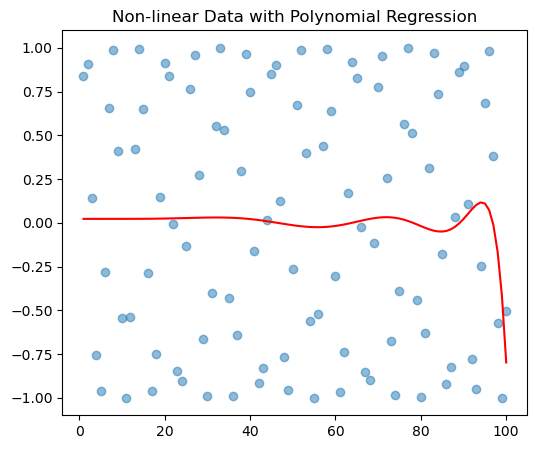

In [20]:
data_1 = np.linspace(1, 100, 100).reshape(-1, 1)
model = LinearRegression()
model.fit(PolynomialFeatures(degree=12).fit_transform(data_1), np.sin(data_1).ravel())
y_pred_1 = model.predict(PolynomialFeatures(degree=12).fit_transform(data_1))

plt.figure(figsize=(6, 5))
plt.scatter(data_1, np.sin(data_1).ravel(), alpha=0.5, label='Data')
plt.plot(data_1, y_pred_1, color='red', label='Predicted')
plt.title('Non-linear Data with Polynomial Regression')

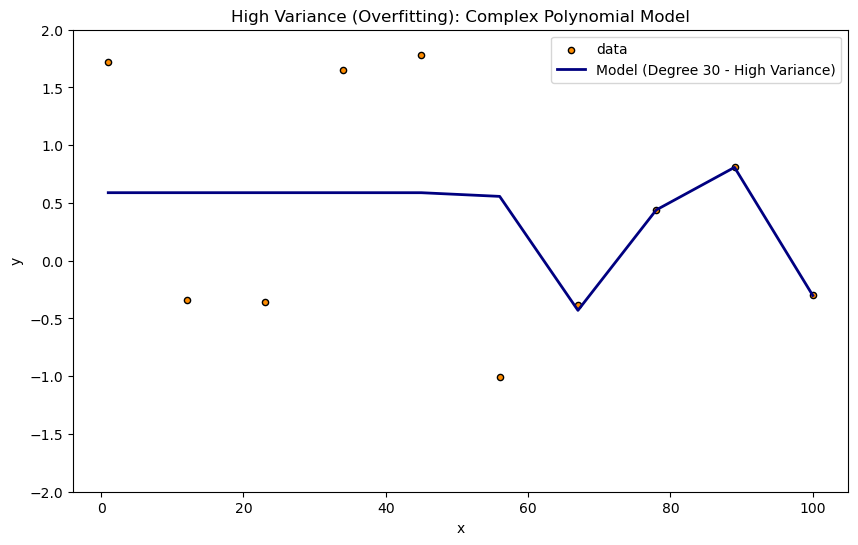

Mean Squared Error for High Variance Model: 0.81


In [21]:
# Create a pipeline with polynomial features (degree 30) and Linear Regression
degree = 30
model_high_variance = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_high_variance.fit(X, y)

# Make predictions
y_pred_high_variance = model_high_variance.predict(X)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X, y_pred_high_variance, color="navy", linewidth=2, label="Model (Degree 30 - High Variance)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("High Variance (Overfitting): Complex Polynomial Model")
plt.legend()
plt.ylim(-2, 2)
plt.show()

print(f"Mean Squared Error for High Variance Model: {mean_squared_error(y, y_pred_high_variance):.2f}")

c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.773e+00, tolerance: 9.603e-04
  model = cd_fast.enet_coordinate_descent(


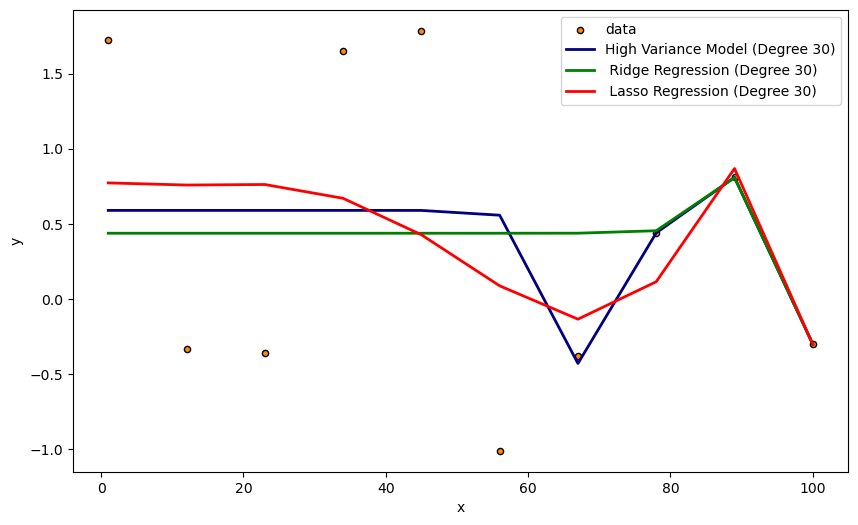

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = make_pipeline(PolynomialFeatures(degree=30), Ridge(alpha=1.0))
ridge_model.fit(X, y)
y_pred_ridge = ridge_model.predict(X)

from sklearn.linear_model import Lasso
lasso_model = make_pipeline(PolynomialFeatures(degree=30), Lasso(alpha=0.1))
lasso_model.fit(X, y)
y_pred_lasso = lasso_model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X, y_pred_high_variance, color="navy", linewidth=2, label="High Variance Model (Degree 30)")
plt.plot(X, y_pred_ridge, color="green", linewidth=2, label=" Ridge Regression (Degree 30)")
plt.plot(X, y_pred_lasso, color="red", linewidth=2, label=" Lasso Regression (Degree 30)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

ridge_cv_scores = cross_val_score(ridge_model, X, y, cv=5, scoring='neg_mean_squared_error')
lasso_cv_scores = cross_val_score(lasso_model, X, y, cv=5, scoring='neg_mean_squared_error')

print("Ridge Regression CV Scores:", ridge_cv_scores)
print("Lasso Regression CV Scores:", lasso_cv_scores)

# compare with simple train-test results.
train_test_ridge = ridge_model.score(X, y)
train_test_lasso = lasso_model.score(X, y)

print("Ridge Regression Train-Test Score:", train_test_ridge)
print("Lasso Regression Train-Test Score:", train_test_lasso)

Ridge Regression CV Scores: [-1.17868561e+00 -1.08484497e+00 -1.95727123e+00 -4.68306389e-01
 -2.32959618e+10]
Lasso Regression CV Scores: [-1.27092112e+01 -1.22353534e+00 -1.76827284e+00 -4.95699244e-01
 -5.65352180e+06]
Ridge Regression Train-Test Score: 0.0697362902414449
Lasso Regression Train-Test Score: 0.21586632621473423


c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Priyansh\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Priyansh\anaconda3\Lib\site-packages